1. Import des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


2. Simulation du processus AR(2)

In [2]:
np.random.seed(42)

# Paramètres
n = 500
phi1 = -0.3
phi2 = 0.4
sigma = 1

# Bruit blanc
eps = np.random.normal(0, sigma, n)

# Initialisation
y = np.zeros(n)

# Simulation
for t in range(2, n):
    y[t] = phi1 * y[t-1] + phi2 * y[t-2] + eps[t]


3. Plot simple de la série

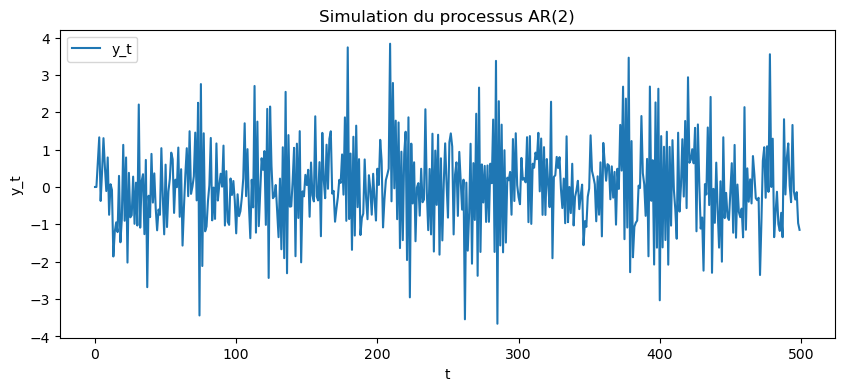

In [3]:
plt.figure(figsize=(10,4))
plt.plot(y, label="y_t")
plt.title("Simulation du processus AR(2)")
plt.xlabel("t")
plt.ylabel("y_t")
plt.legend()
plt.show()


4. Corrélogramme : ACF et PACF

Fonction d'autocorrélation (ACF)


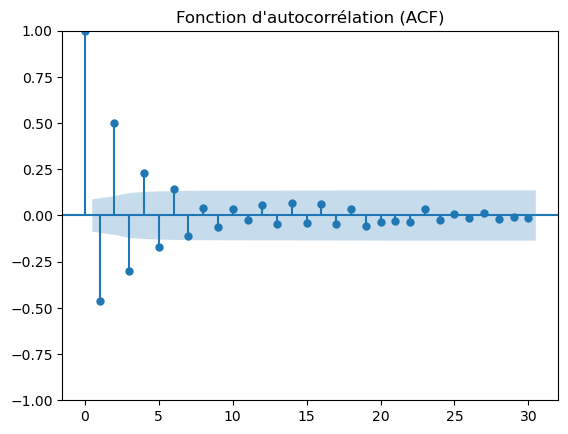

In [4]:
print("Fonction d'autocorrélation (ACF)")
plot_acf(y, lags=30)
plt.title("Fonction d'autocorrélation (ACF)")
plt.show()

Fonction d'autocorrélation simple (PACF)


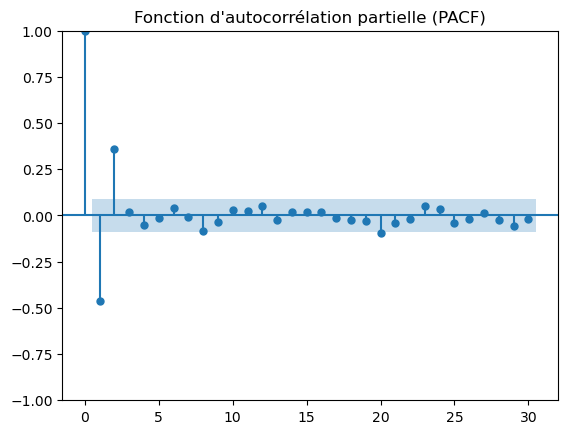

In [5]:
print("Fonction d'autocorrélation simple (PACF)")
plot_pacf(y, lags=30, method="ywm")
plt.title("Fonction d'autocorrélation partielle (PACF)")
plt.show()


5. Estimation du modèle AR(2)

In [6]:
model = sm.tsa.ARIMA(y, order=(2,0,0))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -699.057
Date:                Mon, 02 Feb 2026   AIC                           1406.114
Time:                        09:21:35   BIC                           1422.972
Sample:                             0   HQIC                          1412.729
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0069      0.048      0.146      0.884      -0.087       0.100
ar.L1         -0.2936      0.042     -7.014      0.000      -0.376      -0.212
ar.L2          0.3619      0.045      8.075      0.0

6. Test d’autocorrélation (Q-stat / Ljung–Box)

In [7]:
ljung_box = acorr_ljungbox(result.resid, lags=[10, 20], return_df=True)
ljung_box

,lb_stat,lb_pvalue
10,6.545432,0.767548
20,14.840896,0.785438


7. Stationnarité du processus

In [8]:
# Calcul des racines
coeffs = [1, -phi1, -phi2]
roots = np.roots(coeffs)

roots, np.abs(roots)


(array([-0.8,  0.5]), array([0.8, 0.5]))

8. Inversibilité

AR(2) ≡ ARMA(2,0)

Pas de partie MA

L’inversibilité est trivialement satisfaite

In [9]:
print("""
Conclusion :
- Le processus est un AR(2)
- L’ACF décroît progressivement
- La PACF se coupe après le lag 2
- Le modèle AR(2) est bien identifié
- Les résidus sont non autocorrélés (Ljung-Box)
- Le processus est stationnaire si les racines sont > 1
- Le processus est inversible par définition
""")



Conclusion :
- Le processus est un AR(2)
- L’ACF décroît progressivement
- La PACF se coupe après le lag 2
- Le modèle AR(2) est bien identifié
- Les résidus sont non autocorrélés (Ljung-Box)
- Le processus est stationnaire si les racines sont > 1
- Le processus est inversible par définition

